# Chapter 11: Scaling Laws and Emergent Abilities

**Companion notebook** for *Predicting the Next Words* (Osterrieder, 2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch11_scaling_laws_and_emergent_abilities.ipynb)


## What is in this notebook, and what to change in it

Three cells: two on how loss falls with scale, one on how a model gets bigger
without getting slower.

1. **The Kaplan power law plotted three ways**, with GPT-2, Chinchilla and
   GPT-3 marked on the curve. N_c and alpha_N are constants at the top of the
   cell, taken from the paper. It prints the loss the law gives for GPT-2 at
   1.5B parameters, 2.3036, and for GPT-3 at 175B, 1.6044. A hundredfold in
   parameters buys a drop of about 0.70, and the cell prints no unit for it,
   which is worth noticing before quoting the number anywhere.
2. **Chinchilla-optimal N and D for five compute budgets**, from C = 6ND and
   D = 20N. A printed table.
3. **A mixture-of-experts layer with top-k routing**, eight experts and k = 2,
   showing where each token is routed and how many parameters are active against
   how many exist.

Worth being plain about cell 1: it plots a fitted curve and trains nothing. The
claim is that loss falls as a power of scale, and a plotted power law cannot be
evidence for that claim, because the curve is drawn from the answer. The paper's
measurements are the evidence. What the cell gives you is the shape and the
exponent.

Change alpha_N in cell 1 from 0.076 to 0.3 and rerun. The curve steepens and the
three marked models spread apart, and you can see how much of the argument for
scale rests on that one exponent being small. Then change the ratio in cell 2
from 20 to 5 and watch the optimal split move from data towards parameters. The
Chinchilla result is that ratio, and every planning decision downstream follows
from it.


> **This notebook was executed when it was built**, so the output under each
> cell is a real run's and you can read the file without running anything.
> Rebuild it with `python tools/build_notebook.py ch11`.


In [1]:
# Seeded before the chapter's own cells run.
#
# The cells below draw on torch. This notebook is committed with its
# output stored, and a stored number that changes on every rebuild is
# noise printed as a result. The bundle originals are read only and
# cannot be fixed where they live, so they are seeded here instead.
#
# Same seed as tools/claim_instances.py, which produced the slide
# numbers, so a number that appears in both places appears once.
import torch
torch.manual_seed(20260729)
print('seeded torch with 20260729')

seeded torch with 20260729


### 11.1.2 Kaplan et al.: Scaling Laws for Neural Language Models

![Figure 11.1 -- Scaling Law Curves](../figures/fig-11-1.pdf)


Loss at 1.5B params (GPT-2): 2.3036, at 175B params (GPT-3): 1.6044


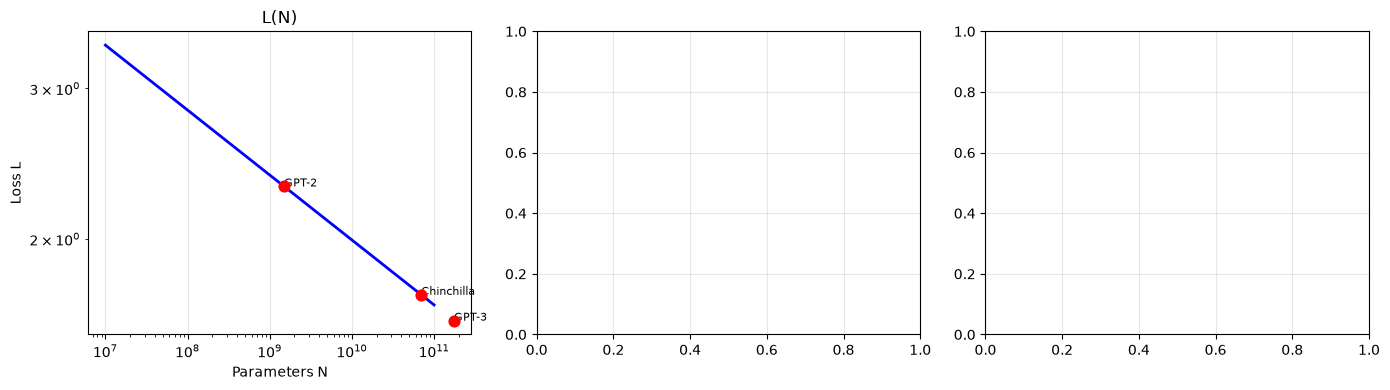

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Kaplan scaling law: L(N) = (N_c / N) ^ alpha_N
N_c, alpha_N = 8.8e13, 0.076
N_vals = np.logspace(7, 11, 50)  # 10M to 100B params
loss_N = (N_c / N_vals) ** alpha_N

# Approximate data points from published models
model_N = np.array([1.5e9, 7e10, 1.75e11])  # GPT-2, Chinchilla, GPT-3
model_L = (N_c / model_N) ** alpha_N

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].loglog(N_vals, loss_N, 'b-', lw=2)
axes[0].scatter(model_N, model_L, c='red', zorder=5, s=60)
for n, l, name in zip(model_N, model_L, ['GPT-2','Chinchilla','GPT-3']):
    axes[0].annotate(name, (n, l), fontsize=8, ha='left')
axes[0].set(xlabel='Parameters N', ylabel='Loss L', title='L(N)')
# Panels (b) and (c) follow identical structure for D and C
for ax in axes: ax.grid(True, alpha=0.3)
print(f"Loss at 1.5B params (GPT-2): {model_L[0]:.4f}, at 175B params (GPT-3): {model_L[2]:.4f}")
plt.tight_layout(); plt.savefig('fig_11_1_scaling_curves.pdf')


### 11.1.4 Using Scaling Laws for Planning


In [3]:
import numpy as np

def chinchilla_optimal(C_flops, ratio=20):
    """Given compute budget C (FLOPs), return optimal N and D."""
    # From C = 6*N*D and D = ratio*N: N = sqrt(C / (6*ratio))
    N_opt = (C_flops / (6 * ratio)) ** 0.5
    D_opt = ratio * N_opt
    return int(N_opt), int(D_opt)

budgets = [1e19, 1e21, 1e23, 1e24, 1e25]
print(f"{'Compute (FLOPs)':>18}  {'N_opt':>14}  {'D_opt (tokens)':>16}  {'D/N':>6}")
print("-" * 60)
for C in budgets:
    N, D = chinchilla_optimal(C)
    print(f"{C:18.0e}  {N:14,}  {D:16,}  {D/N:6.1f}")
# D/N stays ~20 across all budgets -- the Chinchilla invariant


   Compute (FLOPs)           N_opt    D_opt (tokens)     D/N
------------------------------------------------------------
             1e+19     288,675,134     5,773,502,691    20.0
             1e+21   2,886,751,345    57,735,026,918    20.0
             1e+23  28,867,513,459   577,350,269,189    20.0
             1e+24  91,287,092,917  1,825,741,858,350    20.0
             1e+25  288,675,134,594  5,773,502,691,896    20.0


### 11.3.1 Sparse Gating and Top-K Routing

![Figure 11.4 -- MoE Architecture Diagram](../figures/fig-11-4.pdf)


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MoELayer(nn.Module):
    def __init__(self, d_model=64, n_experts=8, top_k=2, d_ff=256):
        super().__init__()
        self.experts = nn.ModuleList(
            [nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(),
                           nn.Linear(d_ff, d_model))
             for _ in range(n_experts)])
        self.gate = nn.Linear(d_model, n_experts, bias=False)
        self.top_k, self.n_experts = top_k, n_experts

    def forward(self, x):                      # x: (B, T, d)
        logits = self.gate(x)                   # (B, T, n_experts)
        topk_val, topk_idx = logits.topk(self.top_k, dim=-1)
        weights = F.softmax(topk_val, dim=-1)   # normalize top-k
        out = torch.zeros_like(x)
        for k in range(self.top_k):
            for e in range(self.n_experts):
                mask = (topk_idx[..., k] == e)
                if mask.any():
                    expert_out = self.experts[e](x[mask])
                    out[mask] += weights[..., k][mask].unsqueeze(-1) * expert_out
        return out

moe = MoELayer(); x = torch.randn(2, 10, 64)
print(f"Input: {x.shape} -> Output: {moe(x).shape}")  # (2,10,64)


Input: torch.Size([2, 10, 64]) -> Output: torch.Size([2, 10, 64])


---

## Summary

This notebook demonstrated the key code examples from Chapter 11: Scaling Laws and Emergent Abilities. For the full mathematical exposition and discussion, refer to the textbook chapter.
